In [9]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import matplotlib
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import KFold

In [10]:
#These are our constants for the script
IMG_SIZE = 64 #Base 2, important for pooling keeps things even
BATCH_SIZE = 32 #images used in each dataset
EPOCHS = 10 #Iterations through the training dataset
LEARNING_RATE = 0.001 #Testing this, may have to change, ran at 86% accuracy, we're chilling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #pytorch said use this
print(f"Using device: {device}")


Using device: cpu


In [11]:
class XRayDataset(Dataset):
    def __init__(self, dir, img_size=IMG_SIZE): #Should be ran with XRayDataset(training_dir)
        self.img_size = img_size
        self.image_paths = []
        self.labels = []

        # 0 = NORMAL, 1 = PNEUMONIA
        self.classes = ['NORMAL', 'PNEUMONIA']

        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(dir, class_name)

            if not os.path.exists(class_dir):
                print(f"Warning: Missing folder - {class_dir}")
                continue

            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                    self.image_paths.append(os.path.join(class_dir, filename))
                    self.labels.append(label_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert('L')
        img = ImageOps.pad(img, (self.img_size, self.img_size), color=0)

        img_array = np.array(img, dtype=np.float32) / 255.0 #set values from [0,1]
        img_array = np.expand_dims(img_array, axis=0) #add extra dimension for pytorch tensor

        return torch.tensor(img_array), torch.tensor(label, dtype=torch.long)

In [12]:
root = 'dataset/chest_xray'

TRAIN_DIR = os.path.join(root, "train")
TEST_DIR = os.path.join(root, "test")

train_full_dataset = XRayDataset(TRAIN_DIR)
test_dataset = XRayDataset(TEST_DIR)

# 80/20 train/validation split
val_size = int(0.2 * len(train_full_dataset))
train_size = len(train_full_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(train_full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training: {train_size}, Validation: {val_size}, Test: {len(test_dataset)}")

Training: 4186, Validation: 1046, Test: 624


In [13]:
class GrayScaleCNN(nn.Module):
    def __init__(self, num_classes):
        super(GrayScaleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 64x64 shrinks in half 3 times -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes) # Automatically sizes output to your folders

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 8 * 8) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:
num_classes = len(train_full_dataset.classes)
model = GrayScaleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    loop = tqdm.tqdm(train_loader, desc=f'Epoch [{epoch+1}/{EPOCHS}]', leave=True)
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
    val_losses.append(val_loss / len(val_loader))

    print(f"  Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Starting Training...


Epoch [1/10]: 100%|██████████| 131/131 [00:39<00:00,  3.29it/s, loss=0.143] 


  Train Loss: 0.2806 | Val Loss: 0.1541


Epoch [2/10]: 100%|██████████| 131/131 [00:39<00:00,  3.31it/s, loss=0.189] 


  Train Loss: 0.1347 | Val Loss: 0.1880


...

  Train Loss: 0.0661 | Val Loss: 0.0693


Epoch [9/10]: 100%|██████████| 131/131 [00:38<00:00,  3.37it/s, loss=0.0387] 


  Train Loss: 0.0504 | Val Loss: 0.0550


Epoch [10/10]: 100%|██████████| 131/131 [00:39<00:00,  3.36it/s, loss=0.00281]


  Train Loss: 0.0476 | Val Loss: 0.0538


In [15]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Metrics
accuracy = np.mean(all_preds == all_labels)
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
sensitivity = tp / (tp + fn)
precision = tp / (tp + fp)
f1 = 2 * precision * sensitivity / (precision + sensitivity)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"AUC-ROC:     {roc_auc:.4f}")

Accuracy:    0.8574
Sensitivity: 1.0000
Precision:   0.8142
F1-Score:    0.8976
AUC-ROC:     0.9714


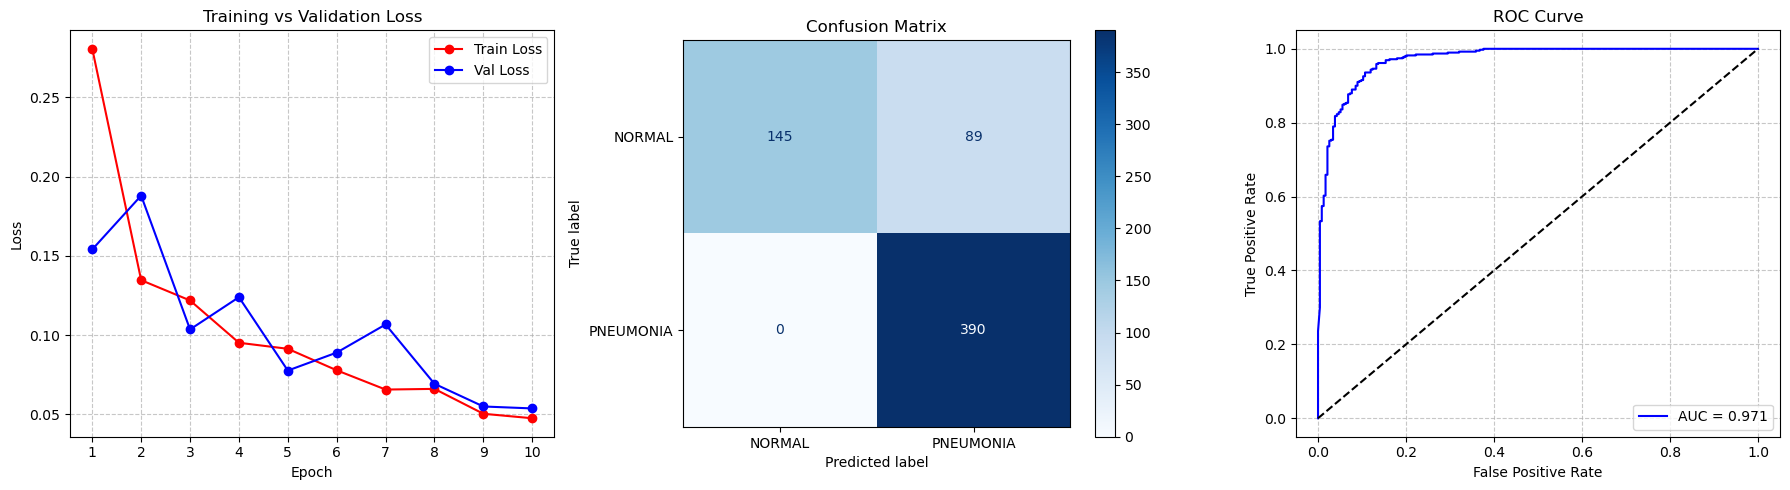

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learning Curves
axes[0].plot(range(1, EPOCHS+1), train_losses, 'r-o', label='Train Loss')
axes[0].plot(range(1, EPOCHS+1), val_losses, 'b-o', label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(range(1, EPOCHS+1))
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix')

# ROC Curve
axes[2].plot(fpr, tpr, 'b-', label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
K = 3 #5 too slow
kfold = KFold(n_splits=K, shuffle=True, random_state=42)
fold_accuracies = []

print(f"{K}-Fold Cross-Validation")
for fold, (train_idx, val_idx) in enumerate(kfold.split(train_full_dataset)):
    train_sub = Subset(train_full_dataset, train_idx)
    val_sub = Subset(train_full_dataset, val_idx)
    train_fold_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
    val_fold_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = GrayScaleCNN(num_classes).to(device)
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=LEARNING_RATE)

    for epoch in range(EPOCHS):
        fold_model.train()
        for inputs, labels in train_fold_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            fold_optimizer.zero_grad()
            loss = criterion(fold_model(inputs), labels)
            loss.backward()
            fold_optimizer.step()

    fold_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_fold_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, preds = torch.max(fold_model(inputs), 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = correct / total
    fold_accuracies.append(acc)
    print(f"  Fold {fold+1}: {acc:.4f}")

print(f"\nMean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")

3-Fold Cross-Validation
  Fold 1: 0.9685
  Fold 2: 0.9633
  Fold 3: 0.9713

Mean Accuracy: 0.9677 ± 0.0033
